In [51]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (proportion_effectsize, proportions_ztest, confint_proportions_2indep)
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from scipy.stats import shapiro, levene
from scipy.stats import ttest_ind, mannwhitneyu
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df = pd.read_csv('E:\\大学\\数分\\archive_white screen\\ab_testing.csv')

In [3]:
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


In [4]:
np.random.seed(42)#固定随机数生成器的种子为 42，实现检验可重复

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     5000 non-null   int64 
 1   Group       5000 non-null   object
 2   Page Views  5000 non-null   int64 
 3   Time Spent  5000 non-null   int64 
 4   Conversion  5000 non-null   object
 5   Device      5000 non-null   object
 6   Location    5000 non-null   object
dtypes: int64(3), object(4)
memory usage: 273.6+ KB


In [6]:
df['converted'] = (df['Conversion'] == 'Yes').astype(int)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     5000 non-null   int64 
 1   Group       5000 non-null   object
 2   Page Views  5000 non-null   int64 
 3   Time Spent  5000 non-null   int64 
 4   Conversion  5000 non-null   object
 5   Device      5000 non-null   object
 6   Location    5000 non-null   object
 7   converted   5000 non-null   int32 
dtypes: int32(1), int64(3), object(4)
memory usage: 293.1+ KB


In [8]:
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location,converted
0,14292,B,3,424,No,Mobile,Northern Ireland,0
1,11682,A,9,342,No,Mobile,Scotland,0
2,19825,A,2,396,No,Desktop,Northern Ireland,0
3,16080,B,4,318,No,Desktop,Wales,0
4,18851,A,1,338,Yes,Desktop,Scotland,1


In [9]:
cr_b = df[df['Group'] == 'B']['converted'].mean()
cr_mde = cr_b + 0.005
alpha = 0.05
power = 0.8

effect_size = proportion_effectsize(cr_mde, cr_b)

analysis = NormalIndPower()

sample_size = analysis.solve_power(effect_size=effect_size,
                                   power=power,
                                   alpha=alpha,
                                   alternative='larger',
                                   ratio = 1)

print(f"Required minimum sample size: {int(float(sample_size))} users per sample")

Required minimum sample size: 60669 users per sample


In [10]:
df = df.rename(columns={
    'User ID': 'user_id',
    'Page Views': 'page_views',
    'Time Spent': 'time_spent',
})#更改数据名

In [11]:
df.head()

,user_id,Group,page_views,time_spent,Conversion,Device,Location,converted
0,14292,B,3,424,No,Mobile,Northern Ireland,0
1,11682,A,9,342,No,Mobile,Scotland,0
2,19825,A,2,396,No,Desktop,Northern Ireland,0
3,16080,B,4,318,No,Desktop,Wales,0
4,18851,A,1,338,Yes,Desktop,Scotland,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5000 non-null   int64 
 1   Group       5000 non-null   object
 2   page_views  5000 non-null   int64 
 3   time_spent  5000 non-null   int64 
 4   Conversion  5000 non-null   object
 5   Device      5000 non-null   object
 6   Location    5000 non-null   object
 7   converted   5000 non-null   int32 
dtypes: int32(1), int64(3), object(4)
memory usage: 293.1+ KB


In [13]:
df['Group'] = df['Group'].astype('category')
df['Device'] = df['Device'].astype("category")
df['Location'] = df['Location'].astype("category")#更改数据类型

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   user_id     5000 non-null   int64   
 1   Group       5000 non-null   category
 2   page_views  5000 non-null   int64   
 3   time_spent  5000 non-null   int64   
 4   Conversion  5000 non-null   object  
 5   Device      5000 non-null   category
 6   Location    5000 non-null   category
 7   converted   5000 non-null   int32   
dtypes: category(3), int32(1), int64(3), object(1)
memory usage: 191.0+ KB


In [15]:
df.duplicated().any()#数据是否有重复，通常配合 df.drop_duplicates() 使用来清洗数据。

False

In [16]:
df.isna().sum()#看缺失值情况

user_id       0
Group         0
page_views    0
time_spent    0
Conversion    0
Device        0
Location      0
converted     0
dtype: int64

In [17]:
df['Group'].value_counts()#T_C各组的数量，均大于60669，可以用于检验,这里不行，但作为练习使用

A    2519
B    2481
Name: Group, dtype: int64

In [18]:
contingency_device = pd.crosstab(df['Group'], df['Device'])
chi2_device, p_device, _, _ = chi2_contingency(contingency_device)

contingency_location = pd.crosstab(df['Group'], df['Location'])
chi2_location, p_location, _, _ = chi2_contingency(contingency_location)

print(f"Device association p-value: {p_device}")
print(f"Location association p-value: {p_location}")#检验分组是否随机，p>0.05则无关，显示为无关

Device association p-value: 0.05338692515743378
Location association p-value: 0.25017827242581403


In [19]:
contingency_views = pd.crosstab(df['Group'], df['page_views'])
chi2_views, p_views, _, _ = chi2_contingency(contingency_views)

contingency_time = pd.crosstab(df['Group'], df['time_spent'])
chi2_time, p_time, _, _ = chi2_contingency(contingency_time)

print(f"Page views association p-value: {p_views}")
print(f"Time spent association p-value: {p_time}")#检验分组是否随机，p>0.05则无关，显示为无关

Page views association p-value: 0.36743748392498277
Time spent association p-value: 0.22810370035156485


In [20]:
df['converted'].unique()

array([0, 1])

In [21]:
#描述性统计01
df.groupby('Group')['converted'].agg(['mean', 'count'])

,mean,count
Group,,
A,0.053990,2519
B,0.140669,2481


In [22]:
df.duplicated('user_id').any()

False

In [23]:
cr_device_sample = (
    df.groupby([df['Device'], df['Group']])['converted']
      .mean()
      .unstack()#将 test_group 转为列（psa / ad），将行索引中的某一层级转换为列标签，把长格式数据变成宽格式
      )#行按周一到周日排序

cr_device_sample

Group,A,B
Device,,
Desktop,0.058682,0.139104
Mobile,0.049412,0.142376


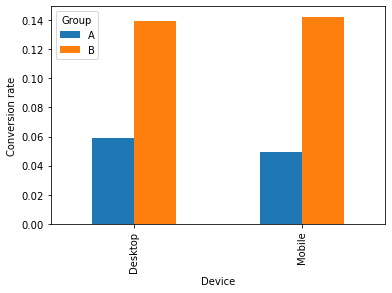

In [24]:
cr_device_sample.plot(kind='bar')
plt.xlabel('Device')
plt.ylabel('Conversion rate')
plt.show()

In [25]:
cr_location_sample = (
    df.groupby([df['Location'], df['Group']])['converted']
      .mean()
      .unstack()#将 test_group 转为列（psa / ad），将行索引中的某一层级转换为列标签，把长格式数据变成宽格式
      )#行按周一到周日排序

cr_location_sample

Group,A,B
Location,,
England,0.069307,0.146875
Northern Ireland,0.050489,0.114650
Scotland,0.049254,0.150573
Wales,0.047695,0.151163


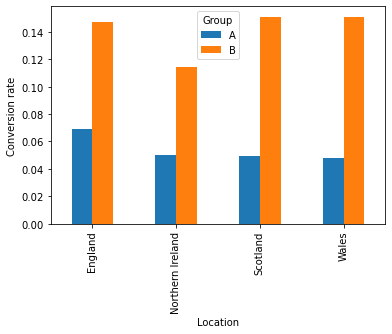

In [26]:
cr_location_sample.plot(kind='bar')
plt.xlabel('Location')
plt.ylabel('Conversion rate')
plt.show()

In [27]:
cr_device_location_B = (
    df[df['Group'] == 'B']
      .groupby(['Device', 'Location'])['converted']
      .mean()
      .unstack()
      .T)

cr_device_location_B

Device,Desktop,Mobile
Location,,
England,0.158209,0.134426
Northern Ireland,0.109375,0.120130
Scotland,0.136364,0.167260
Wales,0.152104,0.150171


In [28]:
df.groupby(['Device', 'Group'])['converted'].agg(['mean', 'std']).unstack()#评估不同设施和实验组的转化率变异性（稳定性）

mean                 std          
Group           A         B         A         B
Device                                         
Desktop  0.058682  0.139104  0.235122  0.346188
Mobile   0.049412  0.142376  0.216811  0.349582

In [29]:
df[df['Group'] == 'B'].groupby('Location')['converted'].agg(['mean', 'std'])

,mean,std
Location,,
England,0.146875,0.354258
Northern Ireland,0.114650,0.318853
Scotland,0.150573,0.357925
Wales,0.151163,0.358505


In [30]:
#Statistical Analysis
conv = df.groupby('Group')['converted'].sum()
n = df.groupby('Group')['converted'].count()

z, p = proportions_ztest(conv, n, alternative='smaller')#单侧检验（检验 ad > psa）
ci_low, ci_high = confint_proportions_2indep(conv['B'], n['B'], conv['A'], n['A'])#计算两比例之差的 95% 置信区间

pd.DataFrame({
    'z_stat': [z],
    'p_value': [p],
    'ci_lower_pp': [ci_low * 100],
    'ci_upper_pp': [ci_high * 100],
    'lift_pp': [(conv['B']/n['B'] - conv['A']/n['A']) * 100]})

,z_stat,p_value,ci_lower_pp,ci_upper_pp,lift_pp
0,-10.354489,1.996576e-25,7.046213,10.309202,8.667941


In [31]:
B = df[df['Group'] == 'B']['converted'].values#转化为纯净的数字表
A = df[df['Group'] == 'A']['converted'].values

n_boot = 5000
boot_diffs = []

for _ in range(n_boot):
    B_sample = np.random.choice(B, size=len(B), replace=True)#从B组数据中随机抽取，抽取次数= B组原样本量，有放回（同一条数据可被多次抽到）
    A_sample = np.random.choice(A, size=len(A), replace=True)
    
    boot_diffs.append(B_sample.mean() - A_sample.mean())

boot_diffs = np.array(boot_diffs)

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
p_value = np.mean(boot_diffs <= 0)

bootstrap_primary = pd.DataFrame({
    'p_value': [f"{p_value:.3f}"],
    'ci_lower_pp': [ci_low * 100],
    'ci_upper_pp': [ci_high * 100],
    'lift_pp': [(B.mean() - A.mean()) * 100]
})

bootstrap_primary#稳健性检验Bootstrap（不依赖正态分布假设，对样本量不均衡更稳健）
#结果z检验表示不显著，并且满足稳健性检验

,p_value,ci_lower_pp,ci_upper_pp,lift_pp
0,0.000,7.051994,10.268094,8.667941


In [32]:
#加入Device的影响，卡方独立性检验，显示为Device分组与Group无关
table = pd.crosstab(df['Device'], df['Group'])

chi2, p_value, _, _ = chi2_contingency(table)

print(f'P-value: {p_value}')

P-value: 0.05338692515743378


In [33]:
# 只有 2 次检验，通常不需要多重比较校正（fdr）（假阳性概率 1 - 0.95^2 ≈ 9.75%，可接受）
device_list = df['Device'].unique()  # 或手动指定 ['Desktop', 'Mobile']

pvals, ci_lower, ci_upper, lifts = [], [], [], []

for device in device_list:
    sub = df[df['Device'] == device]
    
    counts = sub.groupby('Group')['converted'].sum()
    nobs = sub.groupby('Group')['converted'].count()
    
    pvals.append(proportions_ztest(counts, nobs)[1])
    
    low, high = confint_proportions_2indep(counts['B'], nobs['B'], counts['A'], nobs['A'])
    ci_lower.append(low)
    ci_upper.append(high)
    
    lifts.append((counts['B']/nobs['B'] - counts['A']/nobs['A']) / (counts['A']/nobs['A']) * 100)

device_results = pd.DataFrame({
    'device': device_list,
    'p_value': pvals,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper,
    'lift_percent': lifts,
})

device_results
#Mobile 内部：B vs A → 显著
#Desktop 内部：B vs A → 显著

,device,p_value,ci_lower,ci_upper,lift_percent
0,Mobile,3.036981e-15,0.069990,0.116518,188.141373
1,Desktop,1.372920e-11,0.057491,0.103555,137.047702


In [34]:
#探究交互效应
#卡方只能判断分组与设备是否独立（样本量分布），ANOVA 能判断转化率是否受两者共同影响
model_anova = smf.ols('converted ~ C(Group) * C(Device)', data=df).fit()

anova_results = anova_lm(model_anova)

anova_results#双因素方差分析（Two-Way ANOVA），并包含交互项
#Group表示的主效应极为显著
#B在两种设备上都是有效的，但是设备的变化对B的影响没有作用

,df,sum_sq,mean_sq,F,PR(>F)
C(Group),1.0,9.391107,9.391107,109.492706,2.311052e-25
C(Device),1.0,0.011631,0.011631,0.135606,7.127040e-01
C(Group):C(Device),1.0,0.049105,0.049105,0.572523,4.492937e-01
Residual,4996.0,428.503157,0.085769,NaN,NaN


In [35]:
#Robustness check: Bootstrap
n_boot = 5000

results = []

for device in device_list:
    sub = df[df['Device'] == device]
    
    B = sub[sub['Group'] == 'B']['converted'].values
    A = sub[sub['Group'] == 'A']['converted'].values
    
    boot_diffs = []
    
    for _ in range(n_boot):
        B_sample = np.random.choice(B, size=len(B), replace=True)
        A_sample = np.random.choice(A, size=len(A), replace=True)
        
        boot_diffs.append(B_sample.mean() - A_sample.mean())
    
    boot_diffs = np.array(boot_diffs)
    
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
    p_value = np.mean(boot_diffs <= 0)
    
    lift = (B.mean() - A.mean()) / A.mean() * 100
    results.append({
        'device': device,
        'p_value': p_value,
        'ci_lower': ci_low,
        'ci_upper': ci_high,
        'lift_percent': lift
    })

device_bootstrap = pd.DataFrame(results)

reject, pvals_corr, _, _ = multipletests(device_bootstrap['p_value'], method='fdr_bh')

device_bootstrap['p_value_fdr'] = pvals_corr
device_bootstrap['significant'] = reject

device_bootstrap = device_bootstrap[['device', 'p_value', 'p_value_fdr', 'ci_lower', 'ci_upper', 'lift_percent', 'significant']]

device_bootstrap#稳健性检验Bootstrap

,device,p_value,p_value_fdr,ci_lower,ci_upper,lift_percent,significant
0,Mobile,0.0,0.0,0.070449,0.116207,188.141373,True
1,Desktop,0.0,0.0,0.056896,0.103393,137.047702,True


In [36]:
#对location再做一次
table = pd.crosstab(df['Location'], df['Group'])

chi2, p_value, _, _ = chi2_contingency(table)

print(f'P-value: {p_value}')#独立性显著

P-value: 0.25017827242581403


In [37]:
location_list = df['Location'].unique()  # 或手动指定 ['Desktop', 'Mobile']

pvals, ci_lower, ci_upper, lifts = [], [], [], []

for loc in location_list:
    sub = df[df['Location'] == loc]
    
    counts = sub.groupby('Group')['converted'].sum()
    nobs = sub.groupby('Group')['converted'].count()
    
    pvals.append(proportions_ztest(counts, nobs)[1])
    
    low, high = confint_proportions_2indep(counts['B'], nobs['B'], counts['A'], nobs['A'])
    ci_lower.append(low)
    ci_upper.append(high)
    
    lifts.append((counts['B']/nobs['B'] - counts['A']/nobs['A']) / (counts['A']/nobs['A']) * 100)

location_results = pd.DataFrame({
    'Location': location_list,
    'p_value': pvals,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper,
    'lift_percent': lifts,
})

location_results

,Location,p_value,ci_lower,ci_upper,lift_percent
0,Northern Ireland,4.142950e-05,0.033786,0.095160,127.080337
1,Scotland,1.036700e-09,0.068915,0.134899,205.708476
2,Wales,1.091410e-09,0.070604,0.137355,216.937984
3,England,1.140225e-05,0.043329,0.111959,111.919643


In [38]:
model_anova = smf.ols('converted ~ C(Group) * C(Location)', data=df).fit()

anova_results = anova_lm(model_anova)

anova_results#双因素方差分析（Two-Way ANOVA），并包含交互项
#仍然表现出Location对转化率没有影响

,df,sum_sq,mean_sq,F,PR(>F)
C(Group),1.0,9.391107,9.391107,109.585326,2.208815e-25
C(Location),3.0,0.427230,0.142410,1.661791,1.730178e-01
C(Group):C(Location),3.0,0.338458,0.112819,1.316493,2.670997e-01
Residual,4992.0,427.798205,0.085697,NaN,NaN


In [39]:
#Robustness check: Bootstrap
n_boot = 5000

results = []

for loc in location_list:
    sub = df[df['Location'] == loc]
    
    B = sub[sub['Group'] == 'B']['converted'].values
    A = sub[sub['Group'] == 'A']['converted'].values
    
    boot_diffs = []
    
    for _ in range(n_boot):
        B_sample = np.random.choice(B, size=len(B), replace=True)
        A_sample = np.random.choice(A, size=len(A), replace=True)
        
        boot_diffs.append(B_sample.mean() - A_sample.mean())
    
    boot_diffs = np.array(boot_diffs)
    
    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
    p_value = np.mean(boot_diffs <= 0)
    
    lift = (B.mean() - A.mean()) / A.mean() * 100
    results.append({
        'location': loc,
        'p_value': p_value,
        'ci_lower': ci_low,
        'ci_upper': ci_high,
        'lift_percent': lift
    })

location_bootstrap = pd.DataFrame(results)

reject, pvals_corr, _, _ = multipletests(location_bootstrap['p_value'], method='fdr_bh')

location_bootstrap['p_value_fdr'] = pvals_corr
location_bootstrap['significant'] = reject

location_bootstrap = location_bootstrap[['location', 'p_value', 'p_value_fdr', 'ci_lower', 'ci_upper', 'lift_percent', 'significant']]

location_bootstrap#稳健性检验Bootstrap

,location,p_value,p_value_fdr,ci_lower,ci_upper,lift_percent,significant
0,Northern Ireland,0.0,0.0,0.035172,0.094779,127.080337,True
1,Scotland,0.0,0.0,0.069162,0.133621,205.708476,True
2,Wales,0.0,0.0,0.072049,0.136191,216.937984,True
3,England,0.0,0.0,0.044580,0.112031,111.919643,True


In [40]:
df.groupby('Group')['page_views'].agg(['mean', 'std', 'count'])

,mean,std,count
Group,,,
A,7.581580,4.080066,2519
B,7.492946,3.963448,2481


In [42]:
# 提取两组数据
A_pv = df[df['Group'] == 'A']['page_views'].dropna()
B_pv = df[df['Group'] == 'B']['page_views'].dropna()

# 正态性检验（样本量较大时 Shapiro 可能敏感，也可用 kstest 或直接看 Q-Q 图）
print(f"A组正态性 p-value: {shapiro(A_pv)[1]:.4f}")
print(f"B组正态性 p-value: {shapiro(B_pv)[1]:.4f}")

# 方差齐性检验
stat, p_levene = levene(A_pv, B_pv)
print(f"方差齐性 Levene 检验 p-value: {p_levene:.4f}")#不满足正态性（p<0.05），方差齐(p>0.05)

A组正态性 p-value: 0.0000
B组正态性 p-value: 0.0000
方差齐性 Levene 检验 p-value: 0.0763


In [45]:
# 若正态性严重偏离，可使用非参数检验（无论方差齐否）
u_stat, p_value_mw = mannwhitneyu(A_pv, B_pv, alternative='two-sided')
print(f"Mann-Whitney U检验 p-value: {p_value_mw:.4f}")
#表明page views在A/B组之间没有差异

Mann-Whitney U检验 p-value: 0.4247


In [46]:
boot_diffs = []
for _ in range(5000):
    A_sample = np.random.choice(A_pv, size=len(A_pv), replace=True)
    B_sample = np.random.choice(B_pv, size=len(B_pv), replace=True)
    boot_diffs.append(B_sample.mean() - A_sample.mean())

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
print(f"Bootstrap 95% CI for difference: [{ci_low:.2f}, {ci_high:.2f}]")

Bootstrap 95% CI for difference: [-0.31, 0.14]


In [47]:
df.groupby('Group')['time_spent'].agg(['mean', 'std', 'count'])

,mean,std,count
Group,,,
A,241.733227,117.340026,2519
B,243.303910,119.193552,2481


In [48]:
# 提取两组数据
A_ts = df[df['Group'] == 'A']['time_spent'].dropna()
B_ts = df[df['Group'] == 'B']['time_spent'].dropna()

# 正态性检验（样本量较大时 Shapiro 可能敏感，也可用 kstest 或直接看 Q-Q 图）
print(f"A组正态性 p-value: {shapiro(A_ts)[1]:.4f}")
print(f"B组正态性 p-value: {shapiro(B_ts)[1]:.4f}")

# 方差齐性检验
stat, p_levene_ts = levene(A_ts, B_ts)
print(f"方差齐性 Levene 检验 p-value: {p_levene_ts:.4f}")#不满足正态性（p<0.05），方差齐(p>0.05)

A组正态性 p-value: 0.0000
B组正态性 p-value: 0.0000
方差齐性 Levene 检验 p-value: 0.1992


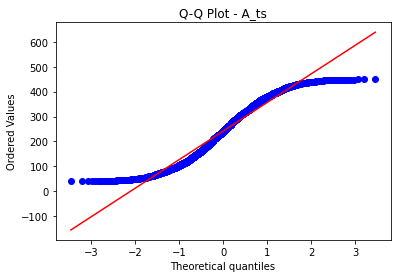

In [52]:
#Q-Q图
stats.probplot(A_ts, dist="norm", plot=plt)
plt.title("Q-Q Plot - A_ts")
plt.show()

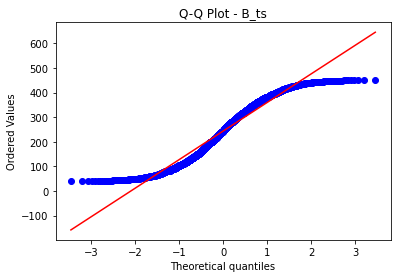

In [53]:
#Q-Q图
stats.probplot(B_ts, dist="norm", plot=plt)
plt.title("Q-Q Plot - B_ts")
plt.show()

In [55]:
# 若正态性严重偏离，可使用非参数检验（无论方差齐否）
u_stat, p_value_mw_ts = mannwhitneyu(A_ts, B_ts, alternative='two-sided')
print(f"Mann-Whitney U检验 p-value: {p_value_mw_ts:.4f}")
#表明time spent在A/B组之间没有差异

Mann-Whitney U检验 p-value: 0.6420


In [56]:
boot_diffs = []
for _ in range(5000):
    A_sample = np.random.choice(A_ts, size=len(A_ts), replace=True)
    B_sample = np.random.choice(B_ts, size=len(B_ts), replace=True)
    boot_diffs.append(B_sample.mean() - A_sample.mean())

ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
print(f"Bootstrap 95% CI for difference: [{ci_low:.2f}, {ci_high:.2f}]")

Bootstrap 95% CI for difference: [-4.96, 8.08]
